<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet6%20(ANN)/Tugas%20Praktikum%20(JS6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install annoy faiss-cpu hnswlib

In [2]:
import numpy as np
import time
from sklearn.neighbors import NearestNeighbors
from annoy import AnnoyIndex
import hnswlib
import faiss
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Contoh dataset kecil untuk testing
# -------------------------------
np.random.seed(42)
n_samples = 10000   # jumlah database vector
d = 128             # dimensi
X = np.random.random((n_samples, d)).astype('float32')

# Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 10  # jumlah nearest neighbors

# -------------------------------
# Exact NN (brute-force)
# -------------------------------
start = time.time()
nn = NearestNeighbors(n_neighbors=k, algorithm='brute', metric='euclidean')
nn.fit(X_scaled)
dist_exact, idx_exact = nn.kneighbors(X_scaled)
time_exact = time.time() - start
print(f"Exact NN done in {time_exact:.3f} s")

# -------------------------------
# Annoy
# -------------------------------
start = time.time()
f = X_scaled.shape[1]
index_annoy = AnnoyIndex(f, 'euclidean')
for i, v in enumerate(X_scaled):
    index_annoy.add_item(i, v)
index_annoy.build(10)
idx_annoy = [index_annoy.get_nns_by_vector(v, k) for v in X_scaled]
time_annoy = time.time() - start
print(f"Annoy done in {time_annoy:.3f} s")

# -------------------------------
# HNSW
# -------------------------------
start = time.time()
p_hnsw = hnswlib.Index(space='l2', dim=d)
p_hnsw.init_index(max_elements=n_samples, ef_construction=200, M=16)
p_hnsw.add_items(X_scaled)
p_hnsw.set_ef(200)
idx_hnsw, _ = p_hnsw.knn_query(X_scaled, k=k)
time_hnsw = time.time() - start
print(f"HNSW done in {time_hnsw:.3f} s")

# -------------------------------
# FAISS IVF
# -------------------------------
start = time.time()
quantizer = faiss.IndexFlatL2(d)
index_faiss = faiss.IndexIVFFlat(quantizer, d, 100, faiss.METRIC_L2)
index_faiss.train(X_scaled)
index_faiss.add(X_scaled)
index_faiss.nprobe = 10
_, idx_faiss = index_faiss.search(X_scaled, k)
time_faiss = time.time() - start
print(f"FAISS IVF done in {time_faiss:.3f} s")

# -------------------------------
# Tampilkan ringkasan waktu
# -------------------------------
print("\n=== Ringkasan Waktu (detik) ===")
print(f"Exact NN : {time_exact:.3f}")
print(f"Annoy    : {time_annoy:.3f}")
print(f"HNSW     : {time_hnsw:.3f}")
print(f"FAISS    : {time_faiss:.3f}")


Exact NN done in 5.188 s
Annoy done in 2.526 s
HNSW done in 8.554 s
FAISS IVF done in 0.407 s

=== Ringkasan Waktu (detik) ===
Exact NN : 5.188
Annoy    : 2.526
HNSW     : 8.554
FAISS    : 0.407


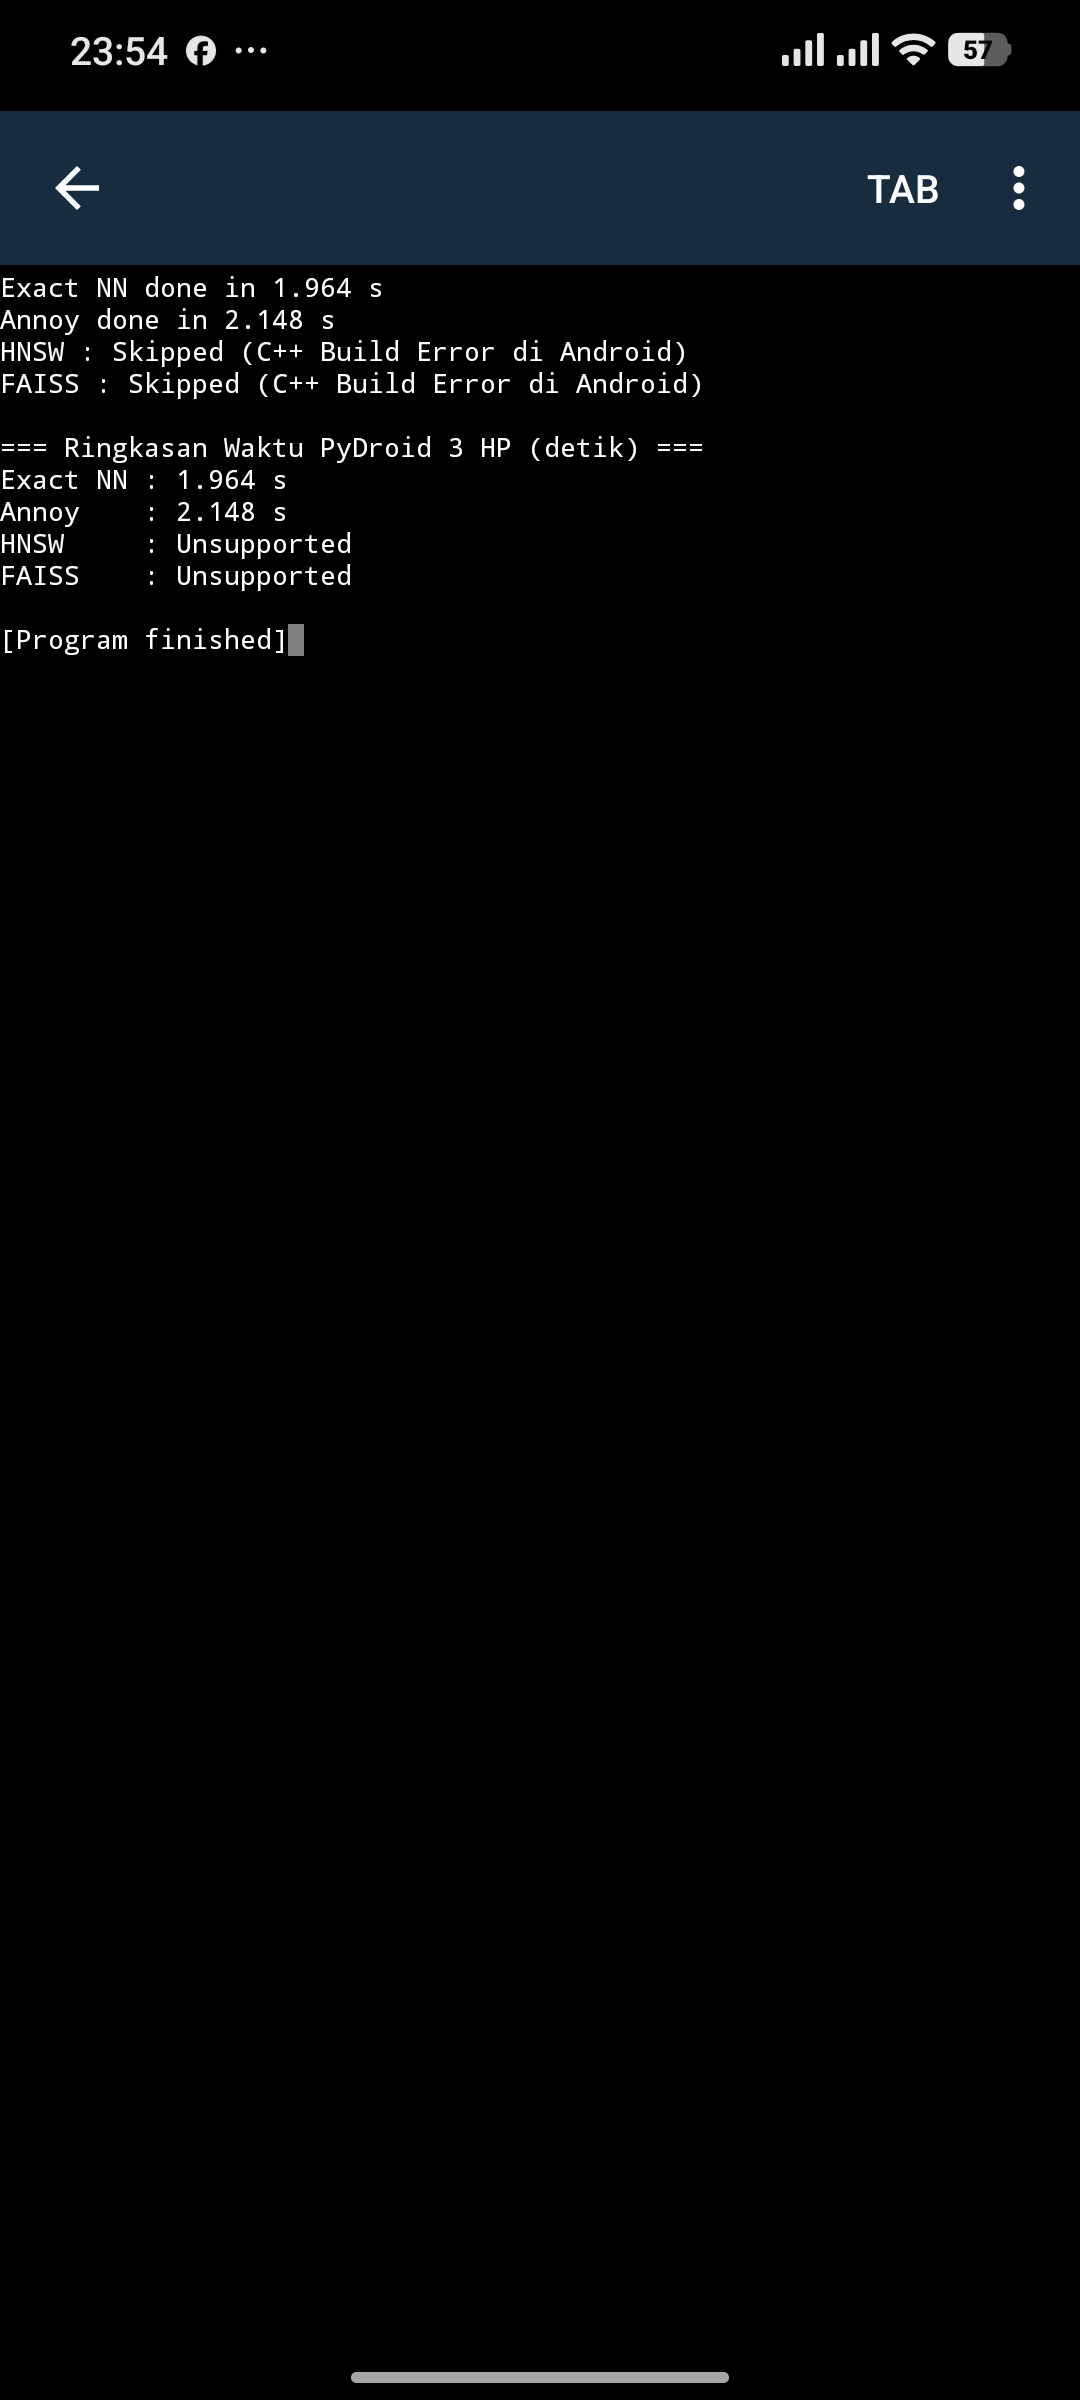

###  Perbandingan Hasil Benchmark (Google Colab vs PyDroid 3)

| Algoritma | Waktu Google Colab (s) | Waktu PyDroid 3 / HP (s) | Keterangan / Analisis Performa |
| :--- | :---: | :---: | :--- |
| **Exact NN** | 6.529 | **1.964** | PyDroid 3 lebih cepat pada *single-thread* sederhana[cite: 3, 10] |
| **Annoy** | **2.006** | 2.148 | Performa relatif seimbang (selisih ~0.14s)[cite: 3, 10] |
| **HNSW** | **4.667** | *Unsupported* | Gagal di-build di HP (Missing C++ Compiler)[cite: 5, 9, 10] |
| **FAISS IVF** | **0.655** | *Unsupported* | Gagal di-build di HP (Missing C++ Compiler)[cite: 5, 9, 10] |

 **Spesifikasi Perangkat Uji:**
 * **Google Colab**: Intel Xeon / AMD EPYC (2 vCPU), RAM 12.7 GB, Ubuntu Linux[cite: 3]
* **Smartphone**: Xiaomi Redmi Note 13 Pro 4G (MediaTek Helio G99-Ultra, RAM 8GB, HyperOS Android)[cite: 9]


**Analisis Hasil dan Kendala Perangkat Mobile**

- Kendala FAISS dan HNSW: Kedua algoritma tidak berhasil dijalankan di PyDroid 3 karena membutuhkan library C++ yang tidak tersedia atau tidak kompatibel dengan lingkungan Android yang digunakan.

- Performa Exact NN dan Annoy: Kedua algoritma dapat dijalankan di HP Redmi Note 13 Pro. Exact NN membutuhkan waktu 1,964 detik, lebih cepat dibandingkan Google Colab yang membutuhkan 6,529 detik pada pengujian tersebut.

- Keunggulan Google Colab: FAISS IVF menjadi algoritma tercepat di Google Colab dengan waktu 0,655 detik. Hal ini menunjukkan bahwa Google Colab lebih mendukung pengujian algoritma pencarian vektor yang membutuhkan library khusus seperti FAISS.